In [43]:
#Data preprocessing libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MaxAbsScaler, StandardScaler, MinMaxScaler #scalers
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer# count vectorizer, feature-extraction
import re #for dealing with punctuations
from scipy.sparse import hstack #to concat a sparse matrix with a numpy array or a pandas dataframe
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, chi2 #for feature selection

#model training libraries
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier

# **DATA PREPROCESSING**

In [44]:
#reading the test and train datasets (and the movies.csv)
train_data=pd.read_csv("train.csv")
test_data=pd.read_csv("test.csv")
movies_data=pd.read_csv("movies.csv")

In [45]:
train_data.head()

,movieid,reviewerName,isFrequentReviewer,reviewText,sentiment
0,marvelous_pirate,Benjamin Henry,False,Henry Selick’s first movie since 2009’s Corali...,POSITIVE
1,tony_montana_frodo_baggins_v_rocky_balboa,Felicia Lopez,False,With a cast that reads like the Vogue Oscar pa...,NEGATIVE
2,darth_vader_katniss_everdeen_sorcerer_donnie_d...,Mr. Charles Burgess,True,Creed II does not give us anything but another...,POSITIVE
3,lara_croft_glimmer,Ryan Barrett,False,"I know what you're thinking, but this is no Li...",POSITIVE
4,jason_bourne_surreal_the_terminator_indiana_jones,Alexander Glover,False,Director Fernando Meirelles tells the story wi...,POSITIVE


In [46]:
test_data.head()

,movieid,reviewerName,isTopCritic,reviewText
0,legend_marty_mcfly_oracle,John Kim,False,Green slowly cranks up the dread with style an...
1,terminator_katniss_everdeen_glimmer,Brian Chaney,False,Philip Noyce's direction is elegant and unforc...
2,james_bond_labyrinth_gollum,Danielle Parker,False,It wouldn't do to say what path Maria ultimate...
3,v_quest_han_solo_wondrous,Brittany Lane,False,Pig is not exactly the arthouse John Wick that...
4,enigma_hulk_surreal_starlight,Justin Willis,False,An imaginative no-budget musical of sorts abou...


In [47]:
movies_data.head()

,movieid,title,audienceScore,rating,ratingContents,releaseDateTheaters,releaseDateStreaming,runtimeMinutes,genre,originalLanguage,director,boxOffice,distributor,soundType
0,han_solo_heroic_myth_wonder_woman,Han Solo Heroic Myth Wonder Woman,50.0,NaN,NaN,NaN,2018-08-25,75.0,"Comedy, Horror, Sci-fi",English,Claude Nicolet,NaN,NaN,NaN
1,voyage_tyler_durden_han_solo_stardust,Voyage Tyler Durden Han Solo Stardust,NaN,NaN,NaN,NaN,2020-02-11,114.0,Drama,English,Nathan Haack,NaN,NaN,NaN
2,norman_bates_ferris_bueller_hermione_granger_v...,Norman Bates Ferris Bueller Hermione Granger V...,43.0,NaN,NaN,NaN,NaN,120.0,Drama,Korean,Theresa Smith,NaN,NaN,NaN
3,elegant_hermione_granger,Elegant Hermione Granger,60.0,NaN,NaN,NaN,2020-10-23,90.0,"Action, Mystery & thriller",English,Donald Lewis,NaN,NaN,NaN
4,adventure_rocky_balboa,Adventure Rocky Balboa,70.0,NaN,NaN,NaN,2017-03-27,80.0,"Fantasy, Adventure, Animation",English,Howard Simms,NaN,NaN,NaN


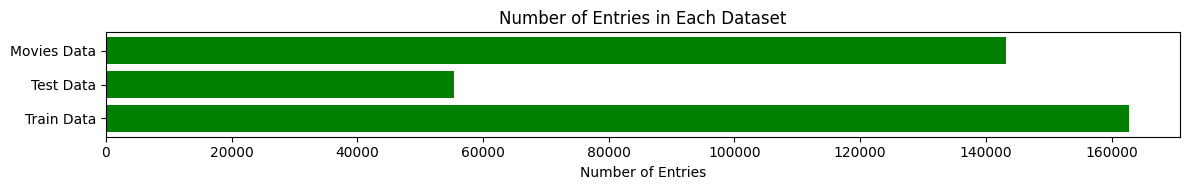

In [48]:
#displaying the number of entries of each of the csvs
plt.figure(figsize=(12, 2))
plt.barh(['Train Data', 'Test Data', 'Movies Data'], 
         [len(train_data), len(test_data), len(movies_data)], color='green')
plt.xlabel('Number of Entries')
plt.title('Number of Entries in Each Dataset')
plt.tight_layout()
plt.show()

In [49]:
#Splitting the datasets
labelEncoder = LabelEncoder(); #for f1-scored grid search evaluation, binary numeric target variable is req

X_train=train_data.iloc[:,:-1] #features for the train_data
y_train=train_data.iloc[:,-1] #labels for the train_data
y_train_binary=labelEncoder.fit_transform(y_train) #binary labels
X_test=test_data.iloc[:,:] #labels for the test_data

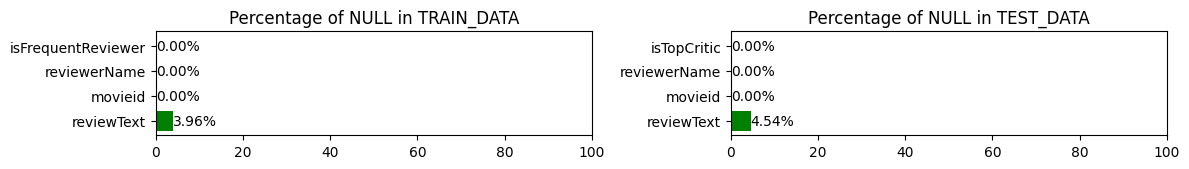

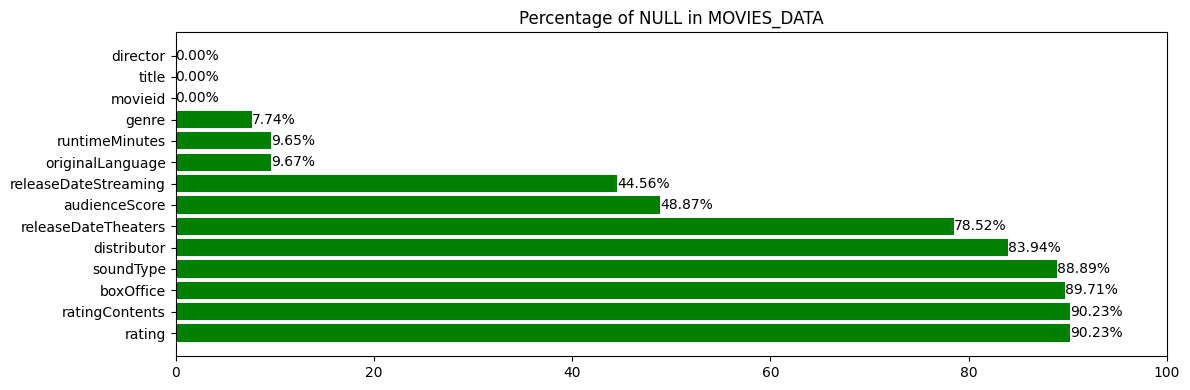

In [50]:
#displaying the null values (percentage) for each of the columns in movies_data
naShare_train = ((X_train.isna().sum() / len(X_train)) * 100).sort_values(ascending=False)
naShare_test = ((X_test.isna().sum() / len(X_test)) * 100).sort_values(ascending=False)
naShare_movies = ((movies_data.isna().sum() / len(movies_data)) * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 1.8))
plt.subplot(1,2,1)
plt.barh(naShare_train.index, naShare_train,color='green')
for index, value in enumerate(naShare_train.values):
    plt.text(value, index, f'{value:.2f}%', va='center')
plt.title('Percentage of NULL in TRAIN_DATA')
plt.xlim(0, 100)
plt.tight_layout()

plt.subplot(1,2,2)
plt.barh(naShare_test.index, naShare_test,color='green')
for index, value in enumerate(naShare_test.values):
    plt.text(value, index, f'{value:.2f}%', va='center')
plt.title('Percentage of NULL in TEST_DATA')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.barh(naShare_movies.index, naShare_movies,color='green')
for index, value in enumerate(naShare_movies.values):
    plt.text(value, index, f'{value:.2f}%', va='center')
plt.title('Percentage of NULL in MOVIES_DATA')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [51]:
#The idea is to merge the movies_data with X_train and X_test so that we could add
#some more information the train and the test sets about the movies. 'movieid' field will
#allow us to merge a given movie in the train or the test dataset with some more info 
#present in the movies_data. Thus it becomes necessary for us to remove duplicates from the 
#movies_data so as to maintain the dimensionality of the train and the test sets. 

#Checking for any duplicates in the dataframes
duplicate_movieids_movies = movies_data.duplicated(subset='movieid')
duplicate_movieids_train = X_train.duplicated(subset='movieid')
duplicate_movieids_test = X_test.duplicated(subset='movieid')
print("NUMBER OF DUPLICATED IDS in movies_data:",len(duplicate_movieids_movies))
print("NUMBER OF DUPLICATED IDS in X_train:",len(duplicate_movieids_train))
print("NUMBER OF DUPLICATED IDS in X_test:",len(duplicate_movieids_test))

NUMBER OF DUPLICATED IDS in movies_data: 143258
NUMBER OF DUPLICATED IDS in X_train: 162758
NUMBER OF DUPLICATED IDS in X_test: 55315


In [52]:
#CLEANING MOVIES_DATA FOR MERGING

#deleting duplicates in movies_data 
duplicate_movieids = movies_data.duplicated(subset='movieid')
movies_data = movies_data.drop_duplicates(subset='movieid', keep='first')

#deleting columns with high null values or of less significance
movies_data.drop(['rating','ratingContents','boxOffice','soundType','distributor','releaseDateTheaters',
                  'audienceScore','releaseDateStreaming','title'],axis=1,inplace=True)

#filling in missing values in 'originalLanguage' and 'genre'
movies_data['originalLanguage'] = movies_data['originalLanguage'].fillna('Unknown')
movies_data['genre'] = movies_data['genre'].fillna('Unknown')

#fixing the string nature of the 'genre' column to list type, which will allow the use of MultiLabelBinarizer
#to help encode the various genres a movie belongs to 
movies_data['genre'] = (movies_data['genre']
                        .str.replace('&', ',')
                        .str.replace(' and ', ',')
                        .str.replace(' ', '')).str.split(',')

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(mlb.fit_transform(movies_data['genre']),
                             columns=mlb.classes_,
                             index=movies_data.index)

#movies_data_mergable consists of the form that is appropriate for merging
movies_data_mergable = pd.concat([movies_data, genre_encoded], axis=1)
movies_data_mergable.drop('genre', axis=1, inplace=True)

In [53]:
# MERGING THE MOVIES_DATA_MERGABLE WITH X_TRAIN AND X_TEST

#dropping columns due to no comments on translability between them
X_train.drop(['isFrequentReviewer'],axis=1,inplace=True)
X_test.drop(['isTopCritic'],axis=1,inplace=True)

#merging the movies_data with X_train and X_test
X_train = pd.merge(X_train, movies_data_mergable, on='movieid', how='left')
X_test = pd.merge(X_test, movies_data_mergable, on='movieid', how='left')

#movieid is of no use now
X_train.drop(['movieid'],axis=1,inplace=True)
X_test.drop(['movieid'],axis=1,inplace=True)

In [54]:
#converting categorical variables in the X_test and the X_train datasets to numerical variables
#to convert the reviewText to numerical form, CountVectorizer is used
#to convert other categorical variables to numerical the CatToNum pipeline is used

ordinal_encoder = OrdinalEncoder()
runtime_imputer = SimpleImputer(strategy='mean')

CatToNum = ColumnTransformer(
    transformers=[
        ('impute_runtime', SimpleImputer(strategy='mean'), ['runtimeMinutes']),
        ('ordinal_encode_reviewerName', ordinal_encoder, ['reviewerName', 'originalLanguage', 'director'])
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocess', CatToNum),
    ('scaler', MinMaxScaler()) #to scale all the numerical features between 0 and 1
])
vectorizer = TfidfVectorizer()
X_train['reviewText'].fillna('Unknown',inplace=True)
X_test['reviewText'].fillna('Unknown',inplace=True)

X_train_reviewVectorized = vectorizer.fit_transform(X_train['reviewText'])
X_train_tobeNum=X_train.drop(['reviewText'], axis=1)
X_train_num=pipeline.fit_transform(X_train_tobeNum)
X_train_num = hstack([X_train_num, X_train_reviewVectorized])#to concatenate the reviewText features with others

X_test_reviewVectorized = vectorizer.transform(X_test['reviewText'])
X_test_tobeNum=X_test.drop(['reviewText'], axis=1)
X_test_num = pipeline.fit_transform(X_test_tobeNum)
X_test_num = hstack([X_test_num, X_test_reviewVectorized])#to concatenate the reviewText features with others

In [55]:
X_test_num.shape,X_train_num.shape

((55315, 65267), (162758, 65267))

In [56]:
#FEATURE SELECTION (65267 features would take a lot of time to train!!!!)
feature_selector = SelectKBest(chi2,k=200)
X_train_reduced = feature_selector.fit_transform(X_train_num, y_train)
X_test_reduced = feature_selector.transform(X_test_num)

In [57]:
X_test_reduced.shape,X_train_reduced.shape

((55315, 200), (162758, 200))

# **MODEL TRAINING**

In [58]:
#will hold the performance of all the models
model_performance=[]

# *Logistic Regression (with Grid Search CV)* #

In [59]:
# Create a logistic regression model
logreg = LogisticRegression(max_iter=10000)

# Define the hyperparameters to tune
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver':['lbfgs','liblinear','sag','saga','newton-cholesky']
}

# Perform grid search with cross-validation using F1-score as the scoring metric
grid_search_logreg = GridSearchCV(logreg, param_grid, cv=5, scoring='f1')
grid_search_logreg.fit(X_train_reduced, y_train_binary)

print("Best Hyperparameters: ", grid_search_logreg.best_params_)
print("Best F1-Score: ", grid_search_logreg.best_score_)
print("Best Estimator: ",grid_search_logreg.best_estimator_)

model_performance.append(('Logistic Regression',grid_search_logreg.best_score_,grid_search_logreg.best_params_))

c:\Users\rishi\AppData\Local\Programs\Python\Python37\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
25 fits failed out of a total of 125.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\rishi\AppData\Local\Programs\Python\Python37\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\rishi\AppData\Local\Programs\Python\Python37\lib\site-packages\sklearn\linear_model\_logistic.py", line 1461, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "c:\Users\rishi\AppData\Local\Programs\Python

Best Hyperparameters:  {'C': 100, 'penalty': 'l2', 'solver': 'sag'}
Best F1-Score:  0.8269905392620809
Best Estimator:  LogisticRegression(C=100, max_iter=10000, solver='sag')


In [23]:
#training the logreg model with the best hyperparameters
#best Hyperparameters:  {'C': 10, 'penalty': 'l2', 'solver': 'saga', max_iter=10000}
#best F1-Score: 0.86

# logreg_model = LogisticRegression(C=10, penalty='l2', max_iter=10000, solver='saga')
predictions_logreg = grid_search_logreg.best_estimator_.predict(X_test_reduced)

#submission score:0.76572 for 500 features (C=1000, penalty='l2', max_iter=10000, solver='newton-cholesky')
#submission score:0.78235 for 1000 features (C=1000, penalty='l2', max_iter=10000, solver='newton-cholesky')
#submission score:0.79591 for 2000 features (C=1000, penalty='l2', max_iter=10000, solver='newton-cholesky')
#submission score:0.79692 for 10,000 features (C=1000, penalty='l2', max_iter=10000, solver='newton-cholesky')
#submission score:0.79215 for 15,000 features (C=1000, penalty='l2', max_iter=10000, solver='newton-cholesky')
#submission score:0.80213 for 5000 features (C=10, penalty='l2', max_iter=10000, solver='saga')

# *XGBoost (with Grid Search CV)* #

In [ ]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier()
param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
}

grid_search_xgb = GridSearchCV(xgb_clf, param_grid, cv=5, scoring='f1')
grid_search_xgb.fit(X_train_reduced, y_train_binary)

print("Best Hyperparameters: ", grid_search_xgb.best_params_)
print("Best F1-Score: ", grid_search_xgb.best_score_)
print("Best Estimator: ",grid_search_xgb.best_estimator_)

model_performance.append(('XGBoost',grid_search_xgb.best_score_,grid_search_xgb.best_params_))

In [ ]:
predictions_xgb = grid_search_xgb.best_estimator_.predict(X_test_reduced)

# *Random Forest (with Grid Search CV)* #

In [ ]:
rf_clf = RandomForestClassifier()

param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
}

grid_search_rf = GridSearchCV(rf_clf, param_grid, cv=5, scoring='f1')
grid_search_rf.fit(X_train_reduced, y_train_binary)

print("Best Hyperparameters: ", grid_search_rf.best_params_)
print("Best F1-Score: ", grid_search_rf.best_score_)
print("Best Estimator: ",grid_search_rf.best_estimator_)

model_performance.append(('Random Forest',grid_search_rf.best_score_,grid_search_rf.best_params_))

In [ ]:
# Best Hyperparameters:  {'C': 1, 'kernel': 'linear'}
# Best F1-Score:  0.8556839171889332
predictions_rf = grid_search_rf.best_estimator_.predict(X_test_reduced)

# **MODEL COMPARISON ON X_TRAIN**

In [ ]:
models, scores, params = zip(*model_performance)

#Plotting the bar chart 
plt.figure(figsize=(5, 5))
plt.bar(models, scores)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Performance')
plt.tight_layout()
plt.show()

# *SVM (with Grid Search CV)* #

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm_model = SVC()

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'sigmoid'],
}

grid_search_svc = GridSearchCV(svm_model, param_grid, cv=2, scoring='f1') #!!!cv is reduced to 2
grid_search_svc.fit(X_train_reduced, y_train_binary)

print("Best Hyperparameters: ", grid_search_svc.best_params_)
print("Best F1-Score: ", grid_search_svc.best_score_)
print("Best Estimator: ",grid_search_svc.best_estimator_)

model_performance.append(('SVC',grid_search_svc.best_score_,grid_search_svc.best_params_))

In [ ]:
# Best Hyperparameters:  {'C': 1, 'kernel': 'linear'}
# Best F1-Score:  0.8556839171889332
predictions_svc = grid_search_svc.best_estimator_.predict(X_test_reduced)

In [ ]:
# Extract model names, scores, and best parameters
models, scores, params = zip(*model_performance)

# Plot the bar chart
plt.figure(figsize=(5, 5))
plt.bar(models, scores)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Performance')
plt.tight_layout()
plt.show()

# **SUBMITTING PREDICTIONS**

In [ ]:
# Save the predictions to a CSV file
predictions_logreg = np.where(predictions_logreg == 1, 'POSITIVE', 'NEGATIVE')
submission = pd.DataFrame({'id': range(len(predictions_logreg)), 'sentiment': predictions_logreg})
submission.to_csv('submission.csv', index=False)

In [ ]:
# #IMPLEMENTING A KNN FOR MILESTONE 3
# from sklearn.neighbors import KNeighborsClassifier

# # Create an instance of KNN
# knn = KNeighborsClassifier()

# # Define the hyperparameters to tune
# param_grid = {
#     'n_neighbors': [3, 5, 7, 9, 11]
# }

# # Perform grid search with cross-validation
# grid_search = GridSearchCV(knn, param_grid, cv=5)
# grid_search.fit(X_train, y_train)

# # Get the best hyperparameters and the best score
# best_params = grid_search.best_params_
# best_score = grid_search.best_score_

# print("Best Hyperparameters: ", best_params)
# print("Best Score: ", best_score)

In [ ]:
# # Train the knn model with the best hyperparameters
# from sklearn.neighbors import KNeighborsClassifier
# knn_model = KNeighborsClassifier(n_neighbors=11)
# knn_model.fit(X_train, y_train)

# # Make predictions on the test data
# predictions = knn_model.predict(X_test)

In [ ]:
# #SUPPORT VECTOR MACHINE
# from sklearn.svm import SVC
# svm = SVC(C=1.0, kernel='rbf', gamma='scale')
# # Fit the SVM to the training data
# svm.fit(X_train_reduced, y_train)
# # Make predictions on the test data
# predictions = svm.predict(X_test_reduced)

In [ ]:
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import f1_score

# # Create an instance of DecisionTreeClassifier
# dt = DecisionTreeClassifier()

# # Fit the Decision Tree to the training data
# dt.fit(X_train, y_train)

# # Make predictions on the test data
# predictions = dt.predict(X_test)

In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import f1_score

# # Create an instance of RandomForestClassifier
# rf = RandomForestClassifier(n_estimators=100, random_state=42)

# # Fit the Random Forest to the training data
# rf.fit(X_train, y_train)

# # Make predictions on the test data
# predictions = rf.predict(X_test)